# Bibliotekos

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LassoCV

from sklearn.cluster import KMeans

# Duomenų paruošimas

In [3]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [4]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.4, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 3832


In [5]:
purpose_translations = {
    'debt_consolidation': 'Skolų konsolidavimas',
    'credit_card': 'Kredito kortelė',
    'all_other': 'Kita',
    'home_improvement': 'Namų remontas',
    'small_business': 'Smulkus verslas',
    'major_purchase': 'Svarbus pirkinys',
    'educational': 'Edukacija'
}

# Normavimas

In [6]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

def denormalize(df_norm, orig_min, orig_max):
    return df_norm * (orig_max - orig_min) + orig_min

numeric_cols = sampled_data.select_dtypes(include=[np.number])

orig_min = numeric_cols.min()
orig_max = numeric_cols.max()

min_max_data = numeric_cols.apply(min_max_normalization)

min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173
1,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767
4,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030


In [7]:
full_min_max_data.to_csv('full_min_max_data.csv', index=False)

# t-SNE

In [8]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(min_max_data)

In [9]:
tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
tsne_df.head()

,tsne_1,tsne_2
0,26.360550,-36.467628
1,-20.327391,-36.450569
2,7.374322,8.128087
3,-7.246502,3.627963
4,8.907294,-32.525677


In [10]:
tsne_df.to_csv('tsne_data.csv', index=False)

# Požymių atrinkimas

## RFE

In [11]:
filtered_data = full_min_max_data[full_min_max_data['purpose'] != 'all_other']

top_3_purposes = filtered_data['purpose'].value_counts().nlargest(3).index.tolist()

print(f"Trys dažniausios grupės: {top_3_purposes}")

debt_consolidation_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[0]]
credit_card_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[1]]
home_improvement_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[2]]

Trys dažniausios grupės: ['debt_consolidation', 'credit_card', 'home_improvement']



Skolų konsolidavimas:
Optimalus požymių skaičius: 8
Geriausi požymiai: ['dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'pub.rec', 'annual.inc']

Kredito kortelė:
Optimalus požymių skaičius: 2
Geriausi požymiai: ['fico', 'inq.last.6mths']

Namų remontas:
Optimalus požymių skaičius: 5
Geriausi požymiai: ['dti', 'fico', 'days.with.cr.line', 'revol.bal', 'inq.last.6mths']


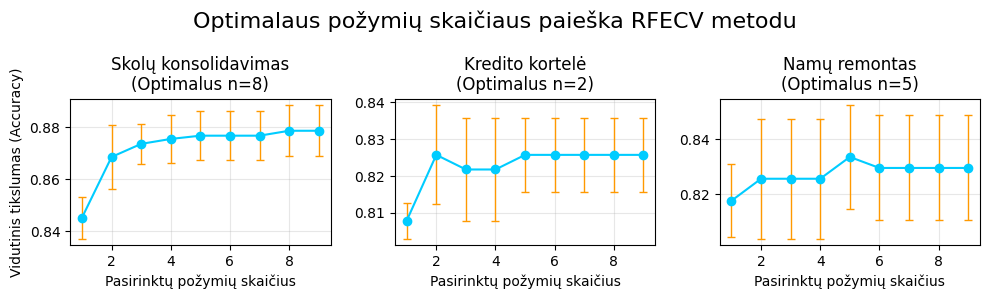

In [12]:
groups = [debt_consolidation_data, credit_card_data, home_improvement_data]
titles = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
file_names = ["rfecv_debt_consolidation.csv", "rfecv_credit_card.csv", "rfecv_home_improvement.csv"]

plt.figure(figsize=(10, 3))

for i, df in enumerate(groups):
    y = df['credit.policy']
    X = df.drop(columns=['credit.policy', 'purpose'], errors='ignore').select_dtypes(include=[np.number])
    
    clf = LogisticRegression(max_iter=2000, solver='liblinear')
    cv = StratifiedKFold(5)
    
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=cv,
        scoring="accuracy",
        min_features_to_select=1,
        n_jobs=-1
    )
    
    rfecv.fit(X, y)

    selected_features = list(X.columns[rfecv.support_])
    
    print(f"\n{titles[i]}:")
    print(f"Optimalus požymių skaičius: {rfecv.n_features_}")
    print(f"Geriausi požymiai: {selected_features}")

    output_df = df[selected_features + ['credit.policy']].copy()
    output_df.to_csv(file_names[i], index=False)
    
    plt.subplot(1, 3, i + 1)

    cv_res = pd.DataFrame({
        "n_features": rfecv.cv_results_["n_features"],
        "mean_test_score": rfecv.cv_results_["mean_test_score"],
        "std_test_score": rfecv.cv_results_["std_test_score"]
    })
    
    plt.errorbar(
        x=cv_res["n_features"],
        y=cv_res["mean_test_score"],
        yerr=cv_res["std_test_score"],
        fmt='-o', color='#00CCFF', ecolor='#FF9900', capsize=3, elinewidth=1, markeredgewidth=1
    )
    
    plt.title(f"{titles[i]}\n(Optimalus n={rfecv.n_features_})")
    plt.xlabel("Pasirinktų požymių skaičius")
    if i == 0: plt.ylabel("Vidutinis tikslumas (Accuracy)")
    plt.grid(alpha=0.3)

plt.suptitle("Optimalaus požymių skaičiaus paieška RFECV metodu", fontsize=16)
plt.tight_layout()
plt.show()

## LassoCV

In [13]:
debt_consolidation_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
1437,0.887693,0.380952,0.209670,0.013196,0.388732,0.074074,0.000000,0.0,0.020476,0,debt_consolidation,0
1438,0.437794,0.333333,0.111737,0.024302,0.312676,0.148148,0.000000,0.0,0.016794,0,debt_consolidation,1
1439,0.656355,0.261905,0.249184,0.021710,0.311737,0.148148,0.166667,0.0,0.017039,0,debt_consolidation,0
1440,0.544385,0.261905,0.353991,0.014127,0.781221,0.148148,0.000000,0.0,0.028333,0,debt_consolidation,0
1441,0.891728,0.238095,0.142833,0.054771,0.615023,0.148148,0.000000,0.0,0.025485,0,debt_consolidation,0


In [14]:
debt_consolidation_data = debt_consolidation_data.drop(columns=['purpose'])
credit_card_data = credit_card_data.drop(columns=['purpose'])
home_improvement_data = home_improvement_data.drop(columns=['purpose'])

--- GRUPĖ: Skolų konsolidavimas ---
Svarbiausių požymių kiekis: 3
Atmesti požymiai: ['days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']

--- GRUPĖ: Kredito kortelė ---
Svarbiausių požymių kiekis: 2
Atmesti požymiai: ['DTI', 'days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']

--- GRUPĖ: Namų remontas ---
Svarbiausių požymių kiekis: 3
Atmesti požymiai: ['days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']



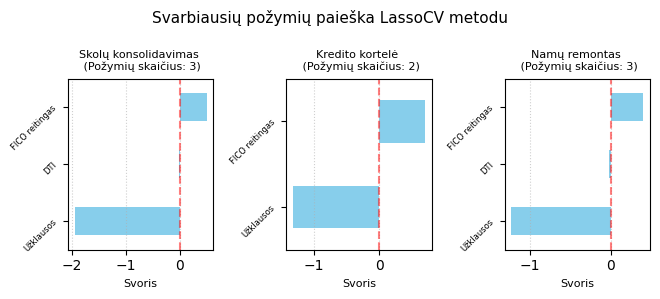

In [15]:
translations = {
    'dti': 'DTI',
    'fico': 'FICO reitingas',
    'inq.last.6mths': 'Užklausos'
}

purposes_list = [
    (debt_consolidation_data, "Skolų konsolidavimas"),
    (credit_card_data, "Kredito kortelė"),
    (home_improvement_data, "Namų remontas")
]

file_names = ["LassoCV_debt_consolidation.csv", "LassoCV_credit_card.csv", "LassoCV_home_improvement.csv"]


fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))

for i, (df, title) in enumerate(purposes_list):
    
    X = df.drop(columns=['credit.policy', 'not.fully.paid'])
    y = df['credit.policy']

    lasso = LassoCV(cv=5, random_state=2026, max_iter=10000).fit(X, y)
    
    translated_index = [translations.get(col, col) for col in X.columns]
    coef = pd.Series(lasso.coef_, index=translated_index)

    orig_coef = pd.Series(lasso.coef_, index=X.columns)
    important_orig = orig_coef[orig_coef != 0].index.tolist()
    df_filtered = df[important_orig + ['credit.policy']].copy()
    df_filtered.to_csv(file_names[i], index=False)
    
    imp_coef = coef[coef != 0].sort_values()

    if not imp_coef.empty:
        imp_coef.plot(kind="barh", ax=axes[i], color='skyblue')
        axes[i].set_title(f"{title} \n (Požymių skaičius: {len(imp_coef)})", fontsize=8)
        axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[i].grid(True, axis='x', linestyle=':', alpha=0.6)
    else:
        axes[i].text(0.5, 0.5, "Reikšmingų požymių nerasta", ha='center')
        axes[i].set_title(title, fontsize=8)

    axes[i].set_xlabel("Svoris", fontsize=8)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=6, rotation=45)


    rejected = coef[coef == 0].index.tolist()
    print(f"--- GRUPĖ: {title} ---")
    print(f"Svarbiausių požymių kiekis: {len(imp_coef)}")
    print(f"Atmesti požymiai: {rejected}\n")

plt.suptitle("Svarbiausių požymių paieška LassoCV metodu", fontsize=11)
plt.tight_layout()
plt.savefig('lasso.png', dpi=300)
plt.show()

# Aprašomoji statistika

## lasso originali

In [16]:
clustered_debt_consolidation = pd.read_csv('clustered_debt_consolidation.csv')
clustered_credit_card = pd.read_csv('clustered_credit_card.csv')
clustered_home_improvement = pd.read_csv('clustered_home_improvement.csv')

In [17]:
purposes = ['debt_consolidation', 'credit_card', 'home_improvement']

def prepare_and_denorm(purpose_name):
    subset = sampled_data[sampled_data['purpose'] == purpose_name].copy()
    subset = subset.rename(columns={'credit.policy': 'label'}).drop(columns=['purpose'])
    return subset

dfs = {p: prepare_and_denorm(p) for p in purposes}

data_w_clusters_debt = dfs['debt_consolidation'].reset_index()
data_w_clusters_credit = dfs['credit_card'].reset_index()
data_w_clusters_home = dfs['home_improvement'].reset_index()

data_w_clusters_debt['label'] = clustered_debt_consolidation['cluster']
data_w_clusters_credit['label'] = clustered_credit_card['cluster']
data_w_clusters_home['label'] = clustered_home_improvement['cluster']

In [18]:
def get_characteristic_table(df, group_col='label'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)
    
    char_table = df.groupby(group_col, observed=False)[numeric_cols].agg([
        'mean', 
        'var', 
        'std', 
        'min', 
        lambda x: x.quantile(0.25), # Q1
        'median', 
        lambda x: x.quantile(0.75), # Q3
        'max'
    ])
    
    char_table.columns = char_table.columns.set_levels(
        ['Vidurkis', 'Variancija', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max'], level=1
    )
    
    return char_table.T

In [19]:
get_characteristic_table(data_w_clusters_debt.drop(columns='index'))

label                              0             1
int.rate   Vidurkis         0.132144  1.202510e-01
           Variancija       0.000556  6.139036e-04
           SD               0.023572  2.477708e-02
           Min              0.074000  6.760000e-02
           Q1               0.118300  1.008000e-01
...                              ...           ...
annual.inc Min          12000.000003  1.000000e+04
           Q1           39000.000191  4.000000e+04
           Mediana      52000.000127  5.500000e+04
           Q3           74999.999811  8.000000e+04
           Max         322400.000124  2.039784e+06

[96 rows x 2 columns]

In [20]:
get_characteristic_table(data_w_clusters_credit.drop(columns='index'))

label                              0              1
int.rate   Vidurkis         0.135007       0.102756
           Variancija       0.000352       0.000278
           SD               0.018759       0.016669
           Min              0.060000       0.067600
           Q1               0.122900       0.089400
...                              ...            ...
annual.inc Min          10000.000000    8499.999996
           Q1           42374.999872   43999.999872
           Mediana      61999.999750   59999.999928
           Q3           90050.000135   84600.000373
           Max         500000.001298  299999.998908

[96 rows x 2 columns]

In [21]:
get_characteristic_table(data_w_clusters_home.drop(columns='index'))

label                              0              1
int.rate   Vidurkis         0.103988       0.130169
           Variancija       0.000508       0.000523
           SD               0.022546       0.022864
           Min              0.060000       0.076800
           Q1               0.085900       0.118300
...                              ...            ...
annual.inc Min          20000.000009   14999.999999
           Q1           54249.500070   50799.999819
           Mediana      78000.000338   69999.999928
           Q3          119801.999610   99503.999667
           Max         719999.999286  279996.001026

[96 rows x 2 columns]

In [50]:
def plot_2x2_boxplots(df, title, group_col='label'):
    numeric_cols = df[['fico', 'dti', 'inq.last.6mths', 'annual.inc']].columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)
    
    features_to_plot = numeric_cols[:4]
    
    translations = {
        'fico': 'FICO įvertinimas',
        'dti': 'Skolos ir pajamų santykis',
        'inq.last.6mths': 'Užklausos per 6 mėn.',
        'annual.inc': 'Metinės pajamos'
    }

    fig, axes = plt.subplots(2, 2, figsize=(6.7, 6))
    axes = axes.flatten()
    
    for i, col in enumerate(features_to_plot):
        sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2', hue=group_col)
        axes[i].set_title(translations.get(col, col), fontsize=14)
        axes[i].set_xlabel('klusteris', fontsize=10)
        axes[i].set_ylabel(translations.get(col, col), fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        
    for j in range(len(features_to_plot), 4):
        fig.delaxes(axes[j])
    
    fig.suptitle(f'Klasterių pasiskirstymas {title} grupėje', fontsize=14)
    plt.tight_layout()
    plt.savefig('boxplot_2x2_grid.png')
    plt.show()

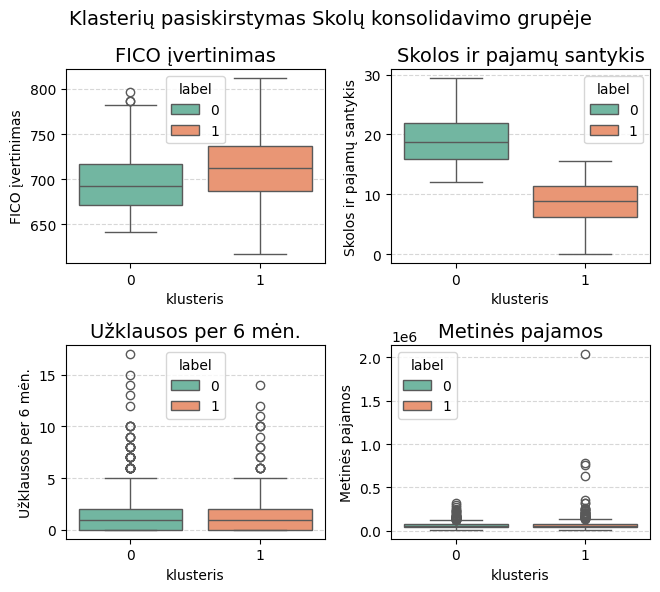

In [51]:
plot_2x2_boxplots(data_w_clusters_debt, 'Skolų konsolidavimo')

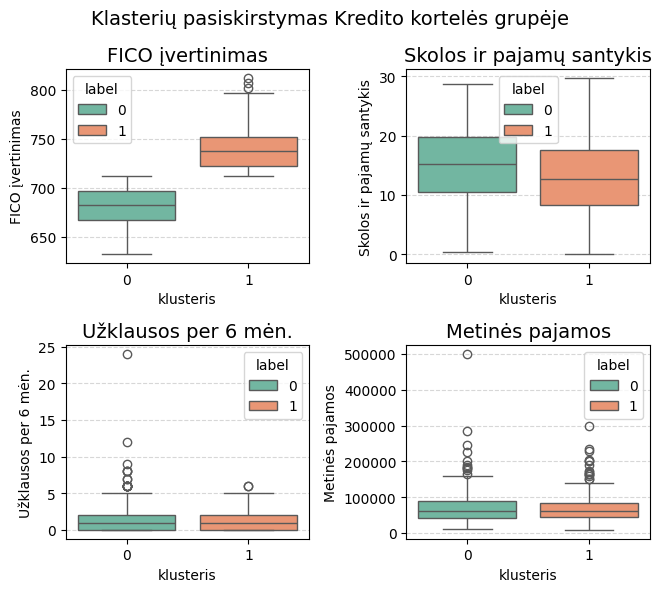

In [52]:
plot_2x2_boxplots(data_w_clusters_credit, 'Kredito kortelės')

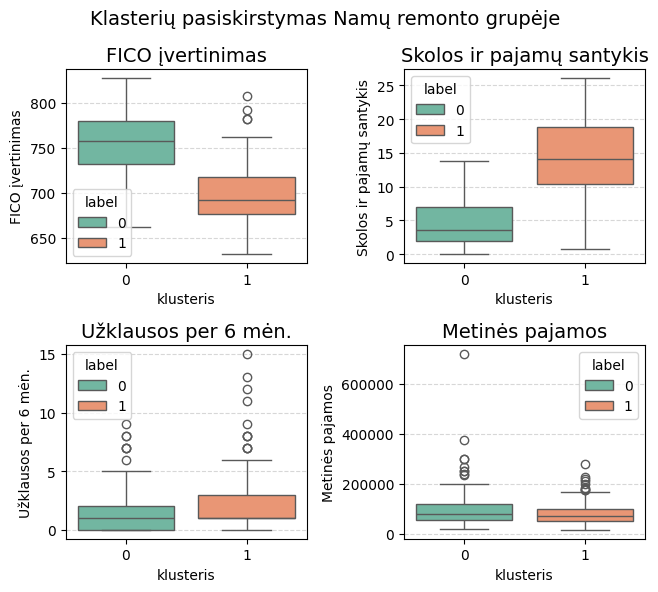

In [53]:
plot_2x2_boxplots(data_w_clusters_home, 'Namų remonto')

## Pilna originali

In [54]:
clustered_debt_consolidation_full = pd.read_csv('clustered_original_full_debt_consolidation.csv')
clustered_credit_card_full = pd.read_csv('clustered_original_full_credit_card.csv')
clustered_home_improvement_full = pd.read_csv('clustered_original_full_home_improvement.csv')

data_w_clusters_debt_full = dfs['debt_consolidation'].reset_index()
data_w_clusters_credit_full = dfs['credit_card'].reset_index()
data_w_clusters_home_full = dfs['home_improvement'].reset_index()

data_w_clusters_debt_full['label'] = clustered_debt_consolidation_full['cluster']
data_w_clusters_credit_full['label'] = clustered_credit_card_full['cluster']
data_w_clusters_home_full['label'] = clustered_home_improvement_full['cluster']

In [55]:
get_characteristic_table(data_w_clusters_debt_full.drop(columns='index'))

label                             0              1
int.rate   Vidurkis    1.130144e-01       0.137578
           Variancija  5.490345e-04       0.000404
           SD          2.343149e-02       0.020096
           Min         6.760000e-02       0.078800
           Q1          9.325000e-02       0.125300
...                             ...            ...
annual.inc Min         1.000000e+04   11388.999997
           Q1          3.770100e+04   39999.999876
           Mediana     5.250000e+04   54999.999768
           Q3          7.500000e+04   78102.000215
           Max         2.039784e+06  324999.999574

[96 rows x 2 columns]

In [56]:
get_characteristic_table(data_w_clusters_debt_full.drop(columns='index'))

label                             0              1
int.rate   Vidurkis    1.130144e-01       0.137578
           Variancija  5.490345e-04       0.000404
           SD          2.343149e-02       0.020096
           Min         6.760000e-02       0.078800
           Q1          9.325000e-02       0.125300
...                             ...            ...
annual.inc Min         1.000000e+04   11388.999997
           Q1          3.770100e+04   39999.999876
           Mediana     5.250000e+04   54999.999768
           Q3          7.500000e+04   78102.000215
           Max         2.039784e+06  324999.999574

[96 rows x 2 columns]

In [57]:
get_characteristic_table(data_w_clusters_home_full.drop(columns='index'))

label                              0              1
int.rate   Vidurkis         0.106411       0.133855
           Variancija       0.000521       0.000488
           SD               0.022835       0.022083
           Min              0.060000       0.085900
           Q1               0.089400       0.121800
...                              ...            ...
annual.inc Min          20400.000003   14999.999999
           Q1           54249.500070   50003.999939
           Mediana      75599.999836   69996.000242
           Q3          105499.999881  105000.000090
           Max         719999.999286  299999.998908

[96 rows x 2 columns]

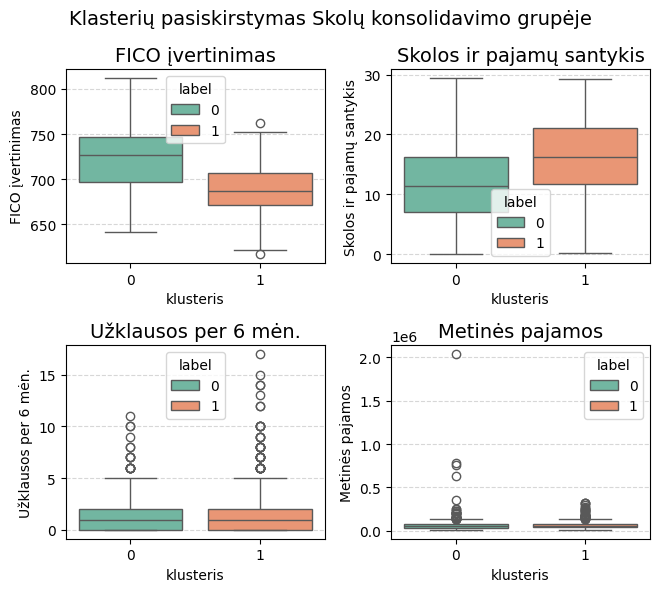

In [58]:
plot_2x2_boxplots(data_w_clusters_debt_full, 'Skolų konsolidavimo')

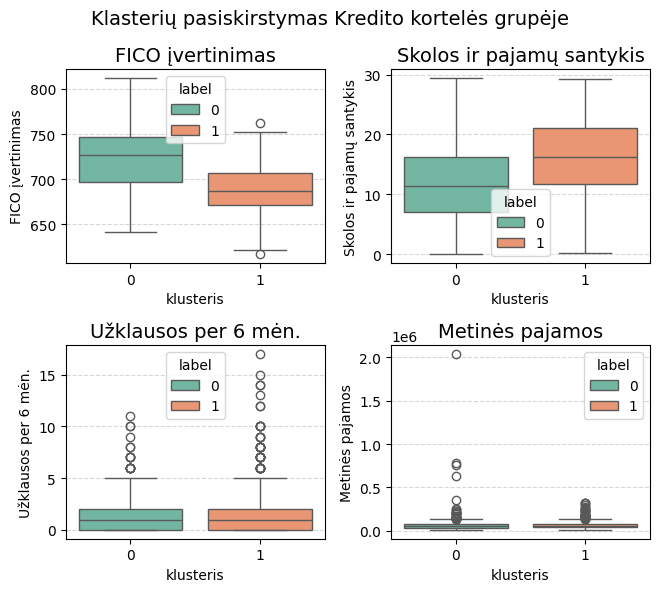

In [59]:
plot_2x2_boxplots(data_w_clusters_debt_full, 'Kredito kortelės')

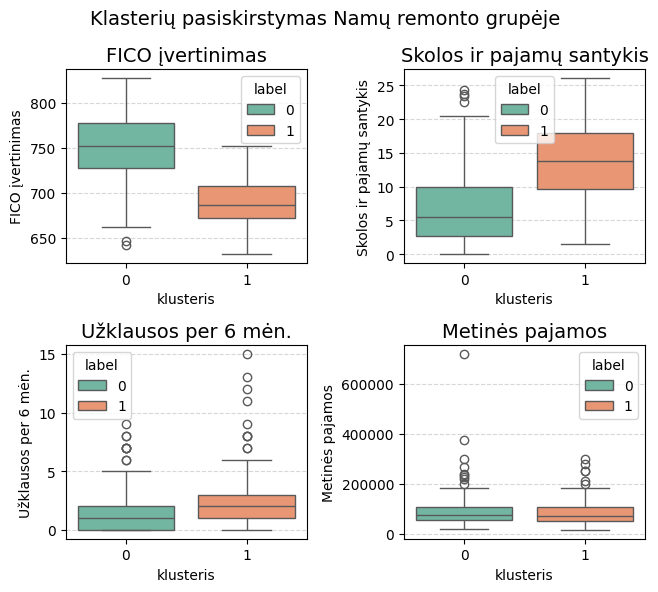

In [60]:
plot_2x2_boxplots(data_w_clusters_home_full, 'Namų remonto')

## lasso tsne

In [61]:
clustered_debt_consolidation_tsne = pd.read_csv('clustered_lasso_tsne_debt_consolidation.csv')
clustered_credit_card_tsne = pd.read_csv('clustered_lasso_tsne_credit_card.csv')
clustered_home_improvement_tsne = pd.read_csv('clustered_lasso_tsne_home_improvement.csv')

data_w_clusters_debt_tsne = dfs['debt_consolidation'].reset_index()
data_w_clusters_credit_tsne = dfs['credit_card'].reset_index()
data_w_clusters_home_tsne = dfs['home_improvement'].reset_index()

data_w_clusters_debt_tsne['label'] = clustered_debt_consolidation_tsne['cluster']
data_w_clusters_credit_tsne['label'] = clustered_credit_card_tsne['cluster']
data_w_clusters_home_tsne['label'] = clustered_home_improvement_tsne['cluster']

In [62]:
get_characteristic_table(data_w_clusters_debt_tsne.drop(columns='index'))

label                              0             1              2  \
int.rate   Vidurkis         0.112223  1.364449e-01       0.144200   
           Variancija       0.000327  3.514243e-04       0.000346   
           SD               0.018091  1.874631e-02       0.018591   
           Min              0.074000  9.010000e-02       0.100800   
           Q1               0.097600  1.247000e-01       0.131100   
...                              ...           ...            ...   
annual.inc Min          14040.000006  1.000000e+04   12000.000003   
           Q1           39000.000191  3.600000e+04   38597.000085   
           Mediana      50865.999852  5.041650e+04   55036.999762   
           Q3           74999.999811  7.470000e+04   74124.999797   
           Max         250000.000789  2.039784e+06  275999.998703   

label                              3              4  
int.rate   Vidurkis         0.103569       0.140582  
           Variancija       0.000345       0.000319  
           SD               0.018571       0.017872  
           Min              0.067600       0.094500  
           Q1               0.089400       0.128700  
...                              ...            ...  
annual.inc Min          14075.999994   11388.999997  
           Q1           42070.000113   39999.999876  
           Mediana      59999.999928   52500.000075  
           Q3           84000.000183   79999.999708  
           Max         780000.001041  324999.999574  

[96 rows x 5 columns]

In [63]:
get_characteristic_table(data_w_clusters_credit_tsne.drop(columns='index'))

label                              0              1
int.rate   Vidurkis         0.135007       0.102756
           Variancija       0.000352       0.000278
           SD               0.018759       0.016669
           Min              0.060000       0.067600
           Q1               0.122900       0.089400
...                              ...            ...
annual.inc Min          10000.000000    8499.999996
           Q1           42374.999872   43999.999872
           Mediana      61999.999750   59999.999928
           Q3           90050.000135   84600.000373
           Max         500000.001298  299999.998908

[96 rows x 2 columns]

In [64]:
get_characteristic_table(data_w_clusters_home_tsne.drop(columns='index'))

label                              0              1
int.rate   Vidurkis         0.102535       0.129894
           Variancija       0.000485       0.000514
           SD               0.022017       0.022670
           Min              0.060000       0.076800
           Q1               0.085900       0.116600
...                              ...            ...
annual.inc Min          20000.000009   14999.999999
           Q1           54684.499948   50003.999939
           Mediana      78000.000338   69999.999928
           Q3          119999.999788   99503.999667
           Max         719999.999286  279996.001026

[96 rows x 2 columns]

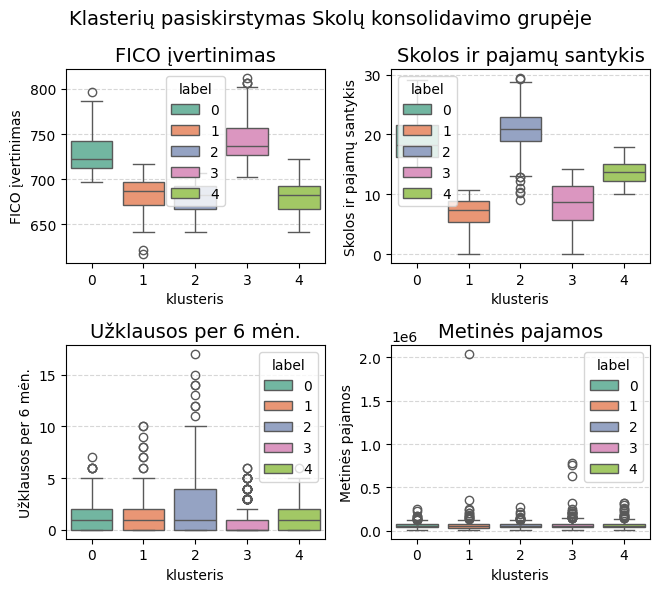

In [65]:
plot_2x2_boxplots(data_w_clusters_debt_tsne, 'Skolų konsolidavimo')

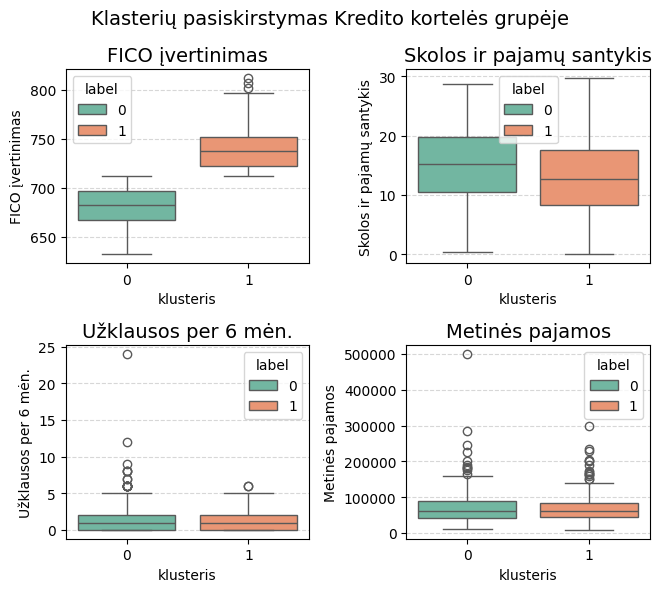

In [66]:
plot_2x2_boxplots(data_w_clusters_credit_tsne, 'Kredito kortelės')

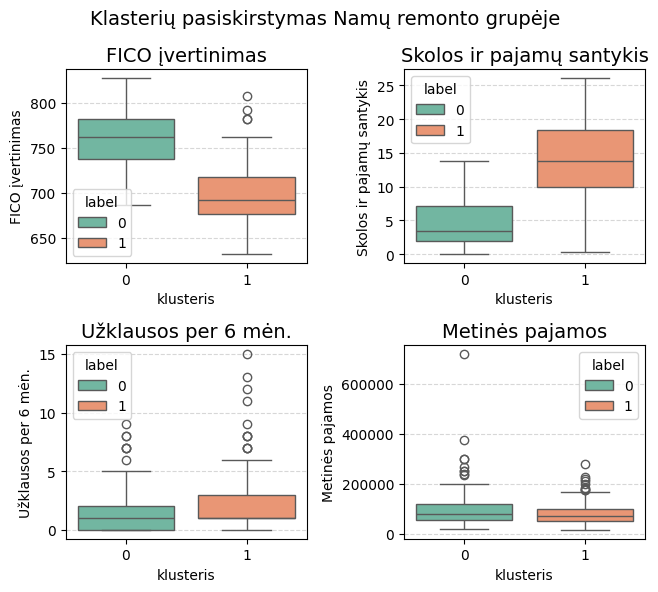

In [67]:
plot_2x2_boxplots(data_w_clusters_home_tsne, 'Namų remonto')